# EDA robusto para sistema de recomendación en Olist

Este notebook reorienta el análisis exploratorio hacia el objetivo real del proyecto: construir la base analítica para un sistema de recomendación que sugiera productos relevantes o complementarios, buscando impactar la **tasa de conversión** y el **ticket promedio**.

> Nota importante: este dataset contiene compras realizadas, pero no contiene visitas, impresiones de productos, clics, carritos abandonados ni sesiones. Por eso, la tasa de conversión no puede calcularse de forma directa. En este EDA se trabaja con aproximaciones útiles para el proyecto: ticket promedio, recurrencia, composición de canasta, co-ocurrencia de categorías y evaluación offline de recomendaciones.

## 1. Preguntas guía del EDA

Este EDA busca responder preguntas alineadas con negocio y modelado:

1. ¿Qué categorías y productos concentran más ventas e ingresos?
2. ¿Cuál es el ticket promedio y cómo cambia por categoría, estado, forma de pago o tamaño de canasta?
3. ¿Qué tan viable es personalizar recomendaciones si muchos clientes tienen una sola compra?
4. ¿Qué productos o categorías suelen comprarse juntos?
5. ¿Qué variables se relacionan con el ticket promedio y la recurrencia?
6. ¿Qué tan bien funciona un recomendador base contra compras futuras usando una evaluación offline?

In [7]:
# !pip install scikit-learn

In [8]:
# ============================================================
# 1. Librerías y configuración general
# ============================================================

import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from collections import Counter, defaultdict
from itertools import combinations

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

pd.set_option('display.max_columns', 120)
pd.set_option('display.max_rows', 120)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

sns.set_theme(style='whitegrid', context='notebook')

In [9]:
# ============================================================
# 2. Carga de datos
# ============================================================

DATA_PATH = Path(r"C:\Users\Ismael2\Downloads\Brazilian E-Commerce Public Dataset by Olist.csv")

if not DATA_PATH.exists():
    DATA_PATH = Path('/mnt/data/Brazilian E-Commerce Public Dataset by Olist.csv')

raw = pd.read_csv(DATA_PATH)

print(f'Filas: {raw.shape[0]:,}')
print(f'Columnas: {raw.shape[1]:,}')
display(raw.head())

Filas: 113,390
Columnas: 39


,Unnamed: 0,order_id,order_item_id,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_id,seller_city,seller_state,seller_zip_code_prefix,payment_type,payment_sequential,payment_installments,price,freight_value,payment_value,shipping_limit_date,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,day_of_purchase,month_of_purchase,year_of_purchase,month/year_of_purchase,order_status,order_unique_id
0,0,00010242fe8c5a6d1ba2dd792cb16214,1,3ce436f183e68e07877b285a838db11a,871766c5855e863f6eccc05f988b23cb,28013,campos dos goytacazes,RJ,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,58.000,598.000,4.000,650.000,28.000,9.000,14.000,48436dade18ac8b2bce089ec2a041202,volta redonda,SP,27277,credit_card,1,2,58.900,13.290,72.190,2017-09-19 09:45:35,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29 00:00:00,Wednesday,September,2017,September-2017,delivered,00010242fe8c5a6d1ba2dd792cb16214-1
1,1,130898c0987d1801452a8ed92a670612,1,e6eecc5a77de221464d1c4eaff0a9b64,0fb8e3eab2d3e79d92bb3fffbb97f188,75800,jatai,GO,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,58.000,598.000,4.000,650.000,28.000,9.000,14.000,48436dade18ac8b2bce089ec2a041202,volta redonda,SP,27277,boleto,1,1,55.900,17.960,73.860,2017-07-05 02:44:11,2017-06-28 11:52:20,2017-06-29 02:44:11,2017-07-05 12:00:33,2017-07-13 20:39:29,2017-07-26 00:00:00,Wednesday,June,2017,June-2017,delivered,130898c0987d1801452a8ed92a670612-1
2,2,532ed5e14e24ae1f0d735b91524b98b9,1,4ef55bf80f711b372afebcb7c715344a,3419052c8c6b45daf79c1e426f9e9bcb,30720,belo horizonte,MG,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,58.000,598.000,4.000,650.000,28.000,9.000,14.000,48436dade18ac8b2bce089ec2a041202,volta redonda,SP,27277,credit_card,1,2,64.900,18.330,83.230,2018-05-23 10:56:25,2018-05-18 10:25:53,2018-05-18 12:31:43,2018-05-23 14:05:00,2018-06-04 18:34:26,2018-06-07 00:00:00,Friday,May,2018,May-2018,delivered,532ed5e14e24ae1f0d735b91524b98b9-1
3,3,6f8c31653edb8c83e1a739408b5ff750,1,30407a72ad8b3f4df4d15369126b20c9,e7c828d22c0682c1565252deefbe334d,83070,sao jose dos pinhais,PR,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,58.000,598.000,4.000,650.000,28.000,9.000,14.000,48436dade18ac8b2bce089ec2a041202,volta redonda,SP,27277,credit_card,1,3,58.900,16.170,75.070,2017-08-07 18:55:08,2017-08-01 18:38:42,2017-08-01 18:55:08,2017-08-02 19:07:36,2017-08-09 21:26:33,2017-08-25 00:00:00,Tuesday,August,2017,August-2017,delivered,6f8c31653edb8c83e1a739408b5ff750-1
4,4,7d19f4ef4d04461989632411b7e588b9,1,91a792fef70ecd8cc69d3c7feb3d12da,0bb98ba72dcc08e95f9d8cc434e9a2cc,36400,conselheiro lafaiete,MG,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,58.000,598.000,4.000,650.000,28.000,9.000,14.000,48436dade18ac8b2bce089ec2a041202,volta redonda,SP,27277,credit_card,1,4,58.900,13.290,72.190,2017-08-16 22:05:11,2017-08-10 21:48:40,2017-08-10 22:05:11,2017-08-11 19:43:07,2017-08-24 20:04:21,2017-09-01 00:00:00,Thursday,August,2017,August-2017,delivered,7d19f4ef4d04461989632411b7e588b9-1


In [10]:
# Revisión de nombres, tipos y valores faltantes
info_df = pd.DataFrame({
    'columna': raw.columns,
    'tipo': raw.dtypes.astype(str).values,
    'nulos': raw.isna().sum().values,
    'pct_nulos': (raw.isna().mean().values * 100).round(2),
    'unicos': raw.nunique(dropna=False).values
}).sort_values('pct_nulos', ascending=False)

display(info_df)

,columna,tipo,nulos,pct_nulos,unicos
0,Unnamed: 0,int64,0,0.000,113390
1,order_id,str,0,0.000,95128
2,order_item_id,int64,0,0.000,21
3,customer_id,str,0,0.000,95128
4,customer_unique_id,str,0,0.000,92081
5,customer_zip_code_prefix,int64,0,0.000,14844
6,customer_city,str,0,0.000,4073
7,customer_state,str,0,0.000,27
8,product_id,str,0,0.000,31625
9,product_category_name,str,0,0.000,73


## 2.1 Limpieza inicial y cuidado con duplicados

El archivo viene como una tabla ya integrada. Eso facilita empezar, pero también puede duplicar información cuando una orden tiene varios productos o varios pagos. Para evitar errores en el ticket promedio:

- Usaremos una tabla a nivel **ítem** eliminando duplicados por `order_unique_id`.
- Usaremos una tabla a nivel **pago** eliminando duplicados por `order_id` y `payment_sequential`.
- Después construiremos una tabla a nivel **orden**, que será la base para ticket, canasta y comportamiento de compra.

In [11]:
# ============================================================
# 3. Limpieza básica
# ============================================================

df = raw.copy()

# Quitar índice heredado si existe
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns='Unnamed: 0')

# Conversión de fechas
date_cols = [
    'shipping_limit_date',
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

# Nos quedamos con órdenes entregadas para analizar compras efectivas.
# Las canceladas son importantes para otros análisis, pero aquí el foco es recomendación basada en compra.
df_delivered = df[df['order_status'].eq('delivered')].copy()

# Nivel ítem: una fila por producto dentro de una orden
items = df_delivered.drop_duplicates('order_unique_id').copy()

# Nivel pago: una fila por secuencia de pago dentro de una orden
payments = df_delivered.drop_duplicates(['order_id', 'payment_sequential']).copy()

print('Filas crudas:', f'{len(df):,}')
print('Filas entregadas:', f'{len(df_delivered):,}')
print('Filas únicas a nivel ítem:', f'{len(items):,}')
print('Filas únicas a nivel pago:', f'{len(payments):,}')
print('Órdenes únicas:', f"{df_delivered['order_id'].nunique():,}")
print('Clientes únicos:', f"{df_delivered['customer_unique_id'].nunique():,}")
print('Productos únicos:', f"{df_delivered['product_id'].nunique():,}")
print('Categorías únicas:', f"{df_delivered['product_category_name'].nunique():,}")

Filas crudas: 113,390
Filas entregadas: 113,383
Filas únicas a nivel ítem: 108,633
Filas únicas a nivel pago: 99,323
Órdenes únicas: 95,122
Clientes únicos: 92,075
Productos únicos: 31,625
Categorías únicas: 73


## 3. Construcción de tabla analítica por orden

Para analizar ticket promedio y comportamiento de compra necesitamos una fila por orden. Esta tabla resume:

- valor de productos,
- flete,
- valor pagado,
- cantidad de productos,
- cantidad de categorías,
- ubicación del cliente,
- forma de pago,
- variables temporales,
- categorías y productos incluidos en la compra.

In [12]:
# ============================================================
# 4. Construcción de tabla por orden
# ============================================================

items['same_state'] = items['customer_state'].eq(items['seller_state'])

orders_base = items.groupby('order_id').agg(
    customer_id=('customer_id', 'first'),
    customer_unique_id=('customer_unique_id', 'first'),
    customer_state=('customer_state', 'first'),
    customer_city=('customer_city', 'first'),
    order_purchase_timestamp=('order_purchase_timestamp', 'first'),
    order_approved_at=('order_approved_at', 'first'),
    order_delivered_customer_date=('order_delivered_customer_date', 'first'),
    order_estimated_delivery_date=('order_estimated_delivery_date', 'first'),
    n_items=('order_unique_id', 'count'),
    n_products=('product_id', 'nunique'),
    n_categories=('product_category_name', 'nunique'),
    items_value=('price', 'sum'),
    freight_value=('freight_value', 'sum'),
    same_state_rate=('same_state', 'mean')
).reset_index()

order_categories = items.groupby('order_id')['product_category_name'].agg(
    lambda x: tuple(sorted(set(x.dropna())))
).rename('categories').reset_index()

order_products = items.groupby('order_id')['product_id'].agg(
    lambda x: tuple(sorted(set(x.dropna())))
).rename('products').reset_index()

orders_payments = payments.groupby('order_id').agg(
    payment_value=('payment_value', 'sum'),
    payment_installments=('payment_installments', 'max'),
    n_payment_methods=('payment_type', 'nunique'),
    payment_type_main=('payment_type', lambda x: x.mode().iloc[0] if len(x.mode()) else np.nan)
).reset_index()

orders = (
    orders_base
    .merge(order_categories, on='order_id', how='left')
    .merge(order_products, on='order_id', how='left')
    .merge(orders_payments, on='order_id', how='left')
)

orders['ticket_total'] = orders['payment_value'].fillna(orders['items_value'] + orders['freight_value'])
orders['avg_item_price'] = orders['items_value'] / orders['n_items'].replace(0, np.nan)
orders['freight_ratio'] = orders['freight_value'] / (orders['items_value'] + orders['freight_value']).replace(0, np.nan)

orders['delivery_days'] = (
    orders['order_delivered_customer_date'] - orders['order_purchase_timestamp']
).dt.total_seconds() / 86400

orders['estimated_days'] = (
    orders['order_estimated_delivery_date'] - orders['order_purchase_timestamp']
).dt.total_seconds() / 86400

orders['delay_days'] = (
    orders['order_delivered_customer_date'] - orders['order_estimated_delivery_date']
).dt.total_seconds() / 86400

orders['late_delivery'] = (orders['delay_days'] > 0).astype(int)
orders['month'] = orders['order_purchase_timestamp'].dt.to_period('M').astype(str)
orders['year'] = orders['order_purchase_timestamp'].dt.year
orders['weekday'] = orders['order_purchase_timestamp'].dt.day_name()

print(f'Tabla por orden: {orders.shape[0]:,} filas x {orders.shape[1]:,} columnas')
display(orders.head())

Tabla por orden: 95,122 filas x 31 columnas


,order_id,customer_id,customer_unique_id,customer_state,customer_city,order_purchase_timestamp,order_approved_at,order_delivered_customer_date,order_estimated_delivery_date,n_items,n_products,n_categories,items_value,freight_value,same_state_rate,categories,products,payment_value,payment_installments,n_payment_methods,payment_type_main,ticket_total,avg_item_price,freight_ratio,delivery_days,estimated_days,delay_days,late_delivery,month,year,weekday
0,00010242fe8c5a6d1ba2dd792cb16214,3ce436f183e68e07877b285a838db11a,871766c5855e863f6eccc05f988b23cb,RJ,campos dos goytacazes,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-20 23:43:48,2017-09-29,1,1,1,58.900,13.290,0.000,"(cool_stuff,)","(4244733e06e7ecb4970a6e2683c13e61,)",72.190,2,1,credit_card,72.190,58.900,0.184,7.614,15.626,-8.011,0,2017-09,2017,Wednesday
1,00018f77f2f0320c557190d7a144bdd3,f6dd3ec061db4e3987629fe6b26e5cce,eb28e67c4c0b83846050ddfb8a35d051,SP,santa fe do sul,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-12 16:04:24,2017-05-15,1,1,1,239.900,19.930,1.000,"(pet_shop,)","(e5f2d52b802189ee658865ca93d83a8f,)",259.830,3,1,credit_card,259.830,239.900,0.077,16.216,18.546,-2.330,0,2017-04,2017,Wednesday
2,000229ec398224ef6ca0657da4fc703e,6489ae5e4333f3693df5ad4372dab6d3,3818d81c6709e39d06b2738a8d3a2474,MG,para de minas,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-22 13:19:16,2018-02-05,1,1,1,199.000,17.870,1.000,"(moveis_decoracao,)","(c777355d18b72b67abbeef9df44fd0fd,)",216.870,5,1,credit_card,216.870,199.000,0.082,7.948,21.393,-13.445,0,2018-01,2018,Sunday
3,00024acbcdf0a6daa1e931b038114c75,d4eb9395c8c0431ee92fce09860c5a06,af861d436cfc08b2c2ddefd0ba074622,SP,atibaia,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-14 13:32:39,2018-08-20,1,1,1,12.990,12.790,1.000,"(perfumaria,)","(7634da152a4610f1595efa32f14722fc,)",25.780,2,1,credit_card,25.780,12.990,0.496,6.147,11.583,-5.436,0,2018-08,2018,Wednesday
4,00042b26cf59d7ce69dfabb4e55b4fd9,58dbd0b2d70206bf40e62cd34e84d795,64b576fb70d441e8f1b2d7d446e483c5,SP,varzea paulista,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-03-01 16:42:31,2017-03-17,1,1,1,199.900,18.140,0.000,"(ferramentas_jardim,)","(ac6c3623068f30de03045865e4e10089,)",218.040,3,1,credit_card,218.040,199.900,0.083,25.114,40.418,-15.304,0,2017-02,2017,Saturday


## 4. KPIs base del proyecto

Estos indicadores no sustituyen las métricas finales del sistema, pero sirven para entender el punto de partida:

- **Ticket promedio:** gasto promedio por orden.
- **Tamaño de canasta:** número de productos por orden.
- **Recurrencia:** clientes con más de una orden.
- **Cold start:** proporción de clientes con una sola compra, problema clave para recomendaciones personalizadas.

In [13]:
# ============================================================
# 5. KPIs base
# ============================================================

customer_summary = orders.groupby('customer_unique_id').agg(
    n_orders=('order_id', 'nunique'),
    total_spend=('ticket_total', 'sum'),
    avg_ticket=('ticket_total', 'mean'),
    total_items=('n_items', 'sum'),
    n_categories=('categories', lambda vals: len(set(c for tup in vals for c in tup))),
    first_purchase=('order_purchase_timestamp', 'min'),
    last_purchase=('order_purchase_timestamp', 'max'),
    state=('customer_state', 'first')
).reset_index()

customer_summary['is_repeat_customer'] = (customer_summary['n_orders'] > 1).astype(int)
customer_summary['customer_lifetime_days'] = (
    customer_summary['last_purchase'] - customer_summary['first_purchase']
).dt.days

kpi = pd.DataFrame({
    'KPI': [
        'Órdenes entregadas',
        'Clientes únicos',
        'Productos únicos',
        'Categorías únicas',
        'Ticket promedio',
        'Ticket mediano',
        'Productos promedio por orden',
        'Categorías promedio por orden',
        'Clientes recurrentes',
        'Tasa de clientes recurrentes',
        'Clientes con una sola compra',
        'Tasa de cold start'
    ],
    'Valor': [
        orders['order_id'].nunique(),
        orders['customer_unique_id'].nunique(),
        items['product_id'].nunique(),
        items['product_category_name'].nunique(),
        orders['ticket_total'].mean(),
        orders['ticket_total'].median(),
        orders['n_items'].mean(),
        orders['n_categories'].mean(),
        customer_summary['is_repeat_customer'].sum(),
        customer_summary['is_repeat_customer'].mean(),
        (customer_summary['n_orders'] == 1).sum(),
        (customer_summary['n_orders'] == 1).mean()
    ]
})

display(kpi)

,KPI,Valor
0,Órdenes entregadas,"95,122.000"
1,Clientes únicos,"92,075.000"
2,Productos únicos,"31,625.000"
3,Categorías únicas,73.000
4,Ticket promedio,160.058
5,Ticket mediano,105.230
6,Productos promedio por orden,1.142
7,Categorías promedio por orden,1.008
8,Clientes recurrentes,"2,741.000"
9,Tasa de clientes recurrentes,0.030


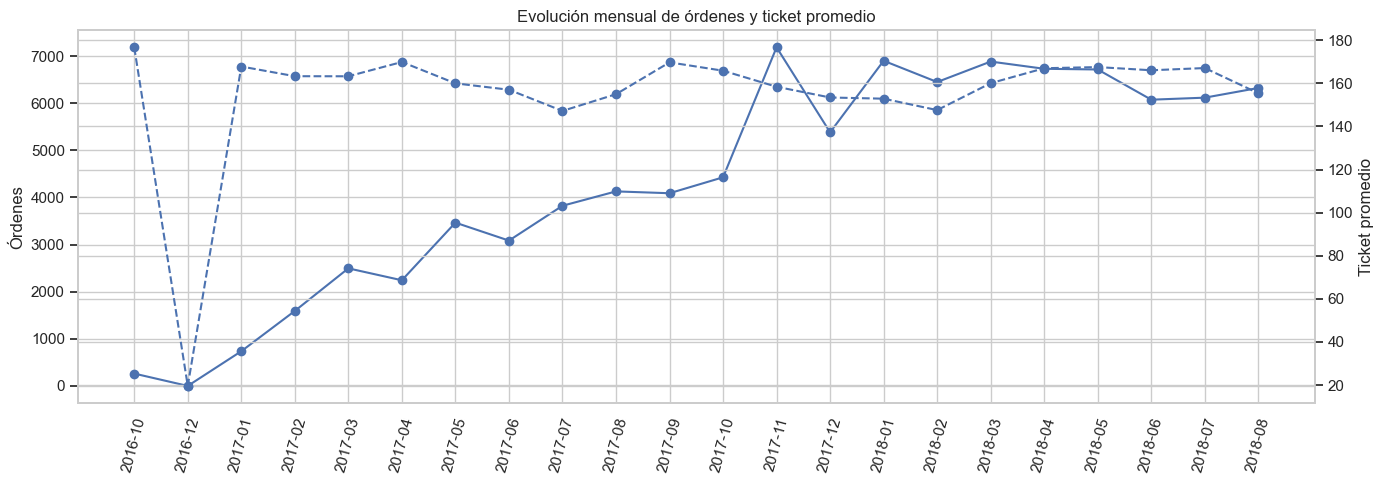

In [14]:
# Evolución mensual de órdenes y ticket promedio
monthly = orders.groupby('month').agg(
    n_orders=('order_id', 'nunique'),
    avg_ticket=('ticket_total', 'mean'),
    revenue=('ticket_total', 'sum')
).reset_index()

fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.plot(monthly['month'], monthly['n_orders'], marker='o', label='Órdenes')
ax1.set_ylabel('Órdenes')
ax1.tick_params(axis='x', rotation=75)

ax2 = ax1.twinx()
ax2.plot(monthly['month'], monthly['avg_ticket'], marker='o', linestyle='--', label='Ticket promedio')
ax2.set_ylabel('Ticket promedio')

plt.title('Evolución mensual de órdenes y ticket promedio')
fig.tight_layout()
plt.show()

## 5. Análisis univariable orientado a compra

Antes de modelar recomendaciones conviene entender cómo se distribuyen el ticket, el número de productos por orden y las categorías. Esto permite detectar sesgos: productos muy populares, clientes de una sola compra o tickets extremos que pueden distorsionar el análisis.

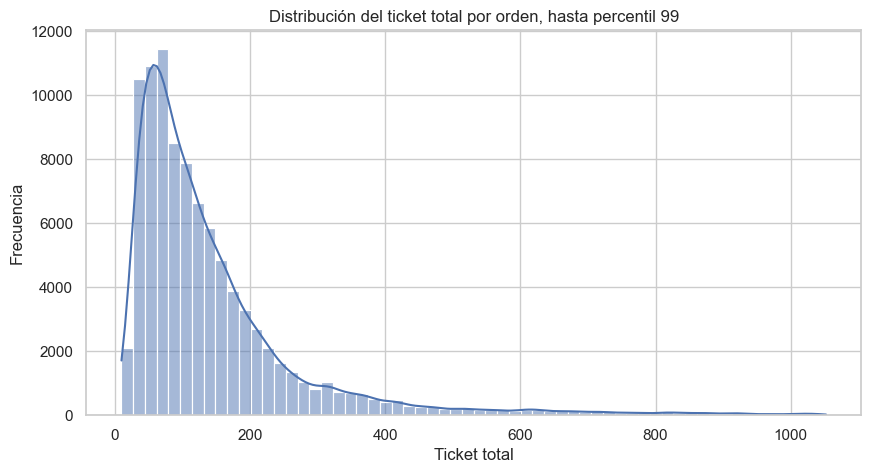

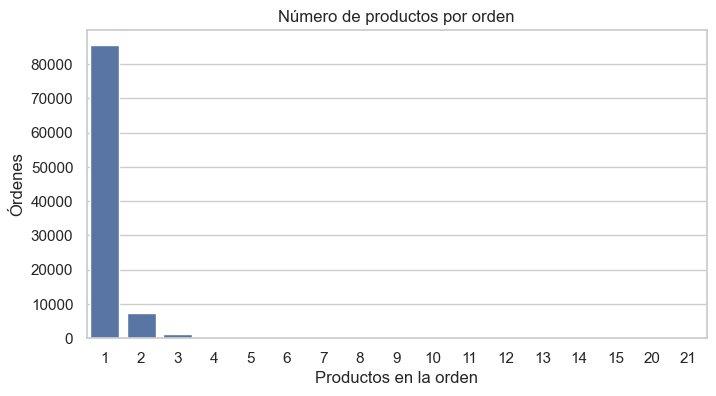

In [15]:
# Distribución de ticket total sin valores extremos visuales
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(orders.loc[orders['ticket_total'] <= orders['ticket_total'].quantile(0.99), 'ticket_total'], bins=60, kde=True, ax=ax)
ax.set_title('Distribución del ticket total por orden, hasta percentil 99')
ax.set_xlabel('Ticket total')
ax.set_ylabel('Frecuencia')
plt.show()

# Tamaño de canasta
fig, ax = plt.subplots(figsize=(8, 4))
sns.countplot(data=orders, x='n_items', ax=ax)
ax.set_title('Número de productos por orden')
ax.set_xlabel('Productos en la orden')
ax.set_ylabel('Órdenes')
plt.show()

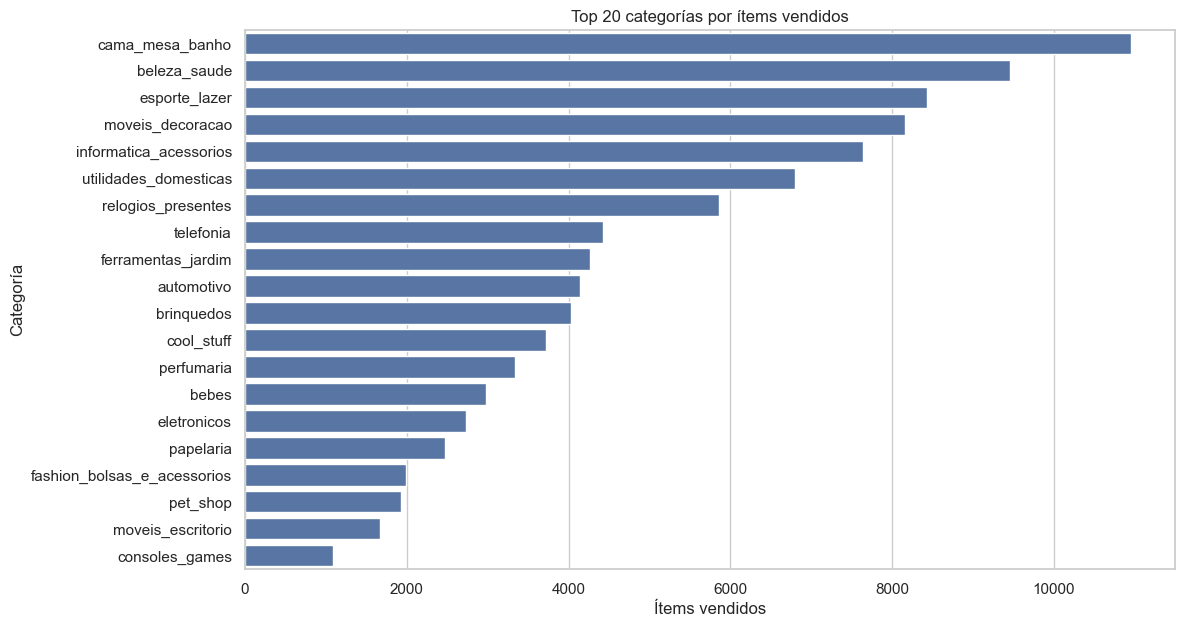

In [16]:
# Top categorías por número de ítems vendidos
top_categories_count = (
    items['product_category_name']
    .value_counts()
    .head(20)
    .reset_index()
)
top_categories_count.columns = ['product_category_name', 'n_items']

plt.figure(figsize=(12, 7))
sns.barplot(data=top_categories_count, y='product_category_name', x='n_items')
plt.title('Top 20 categorías por ítems vendidos')
plt.xlabel('Ítems vendidos')
plt.ylabel('Categoría')
plt.show()

## 6. Ticket promedio y valor por categoría

Para el KPI de ticket promedio no basta con saber qué se vende más. También conviene identificar categorías que generan más ingreso, categorías de ticket alto y categorías que podrían usarse para venta cruzada.

In [17]:
# ============================================================
# 6. Análisis por categoría
# ============================================================

category_stats = items.groupby('product_category_name').agg(
    n_items=('order_unique_id', 'count'),
    n_orders=('order_id', 'nunique'),
    customers=('customer_unique_id', 'nunique'),
    revenue=('price', 'sum'),
    avg_price=('price', 'mean'),
    avg_freight=('freight_value', 'mean')
).reset_index()

category_stats['revenue_share'] = category_stats['revenue'] / category_stats['revenue'].sum()
category_stats['items_share'] = category_stats['n_items'] / category_stats['n_items'].sum()
category_stats['avg_revenue_per_order'] = category_stats['revenue'] / category_stats['n_orders']

category_stats = category_stats.sort_values('revenue', ascending=False)
display(category_stats.head(20))

,product_category_name,n_items,n_orders,customers,revenue,avg_price,avg_freight,revenue_share,items_share,avg_revenue_per_order
11,beleza_saude,9462,8646,8497,"1,232,996.750",130.310,18.912,0.095,0.087,142.609
66,relogios_presentes,5857,5493,5419,"1,165,898.980",199.061,16.752,0.089,0.054,212.252
13,cama_mesa_banho,10952,9271,9007,"1,023,300.770",93.435,18.421,0.078,0.101,110.377
32,esporte_lazer,8428,7527,7338,"954,604.570",113.266,19.383,0.073,0.078,126.824
44,informatica_acessorios,7643,6529,6404,"888,613.620",116.265,18.839,0.068,0.070,136.103
54,moveis_decoracao,8156,6303,6174,"711,493.090",87.236,20.640,0.055,0.075,112.882
72,utilidades_domesticas,6795,5743,5681,"615,628.690",90.600,21.010,0.047,0.063,107.196
26,cool_stuff,3715,3556,3540,"609,964.130",164.190,21.913,0.047,0.034,171.531
8,automotivo,4139,3809,3768,"578,849.350",139.852,21.858,0.044,0.038,151.969
12,brinquedos,4029,3803,3762,"471,097.490",116.927,18.803,0.036,0.037,123.875


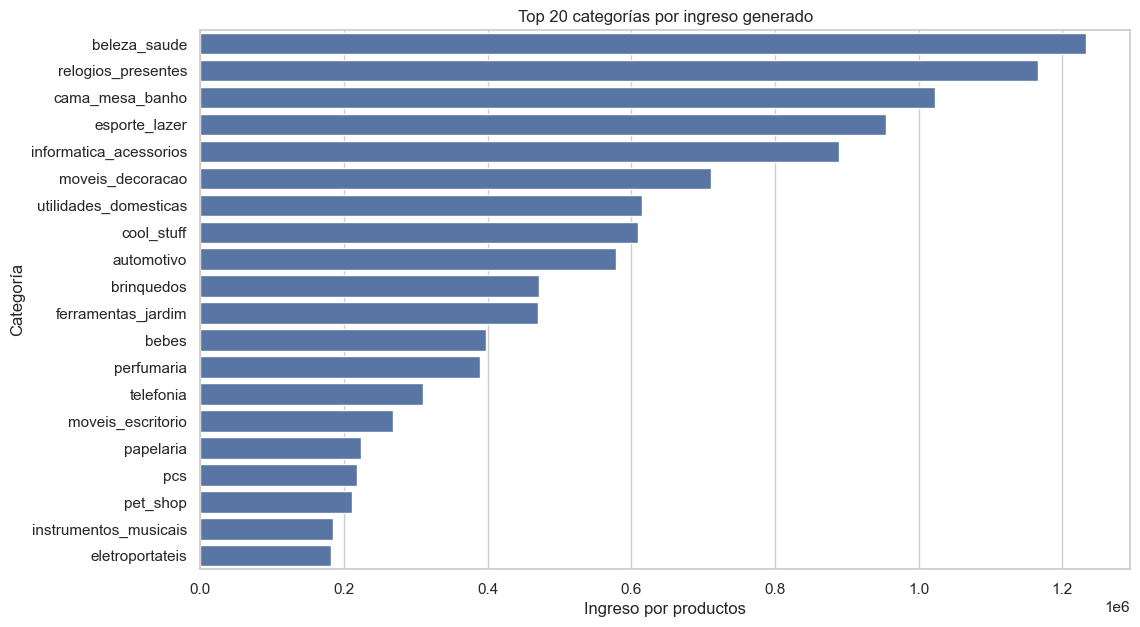

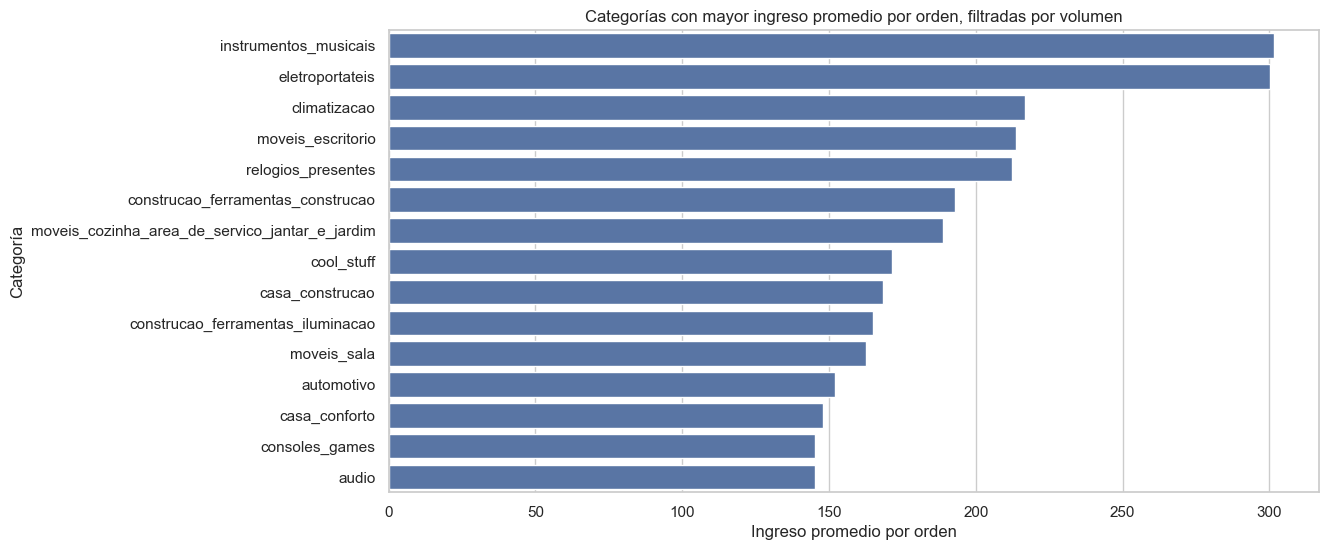

In [18]:
# Top categorías por ingreso
plt.figure(figsize=(12, 7))
sns.barplot(
    data=category_stats.head(20),
    y='product_category_name',
    x='revenue'
)
plt.title('Top 20 categorías por ingreso generado')
plt.xlabel('Ingreso por productos')
plt.ylabel('Categoría')
plt.show()

# Categorías con mayor ticket promedio, filtrando categorías con volumen suficiente
min_orders = category_stats['n_orders'].quantile(0.50)
high_ticket_categories = (
    category_stats[category_stats['n_orders'] >= min_orders]
    .sort_values('avg_revenue_per_order', ascending=False)
    .head(15)
)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=high_ticket_categories,
    y='product_category_name',
    x='avg_revenue_per_order'
)
plt.title('Categorías con mayor ingreso promedio por orden, filtradas por volumen')
plt.xlabel('Ingreso promedio por orden')
plt.ylabel('Categoría')
plt.show()

## 7. Clientes, recurrencia y problema de cold start

Un sistema de recomendación personalizado necesita historial. Si muchos clientes compran una sola vez, el modelo debe combinar:

- recomendaciones populares,
- similitud por categoría,
- patrones geográficos,
- productos complementarios,
- y reglas de negocio para clientes nuevos.

,n_orders,n_customers
0,1,89334
1,2,2520
2,3,175
3,4,29
4,5,9
5,6,3
6,7,3
7,9,1
8,14,1


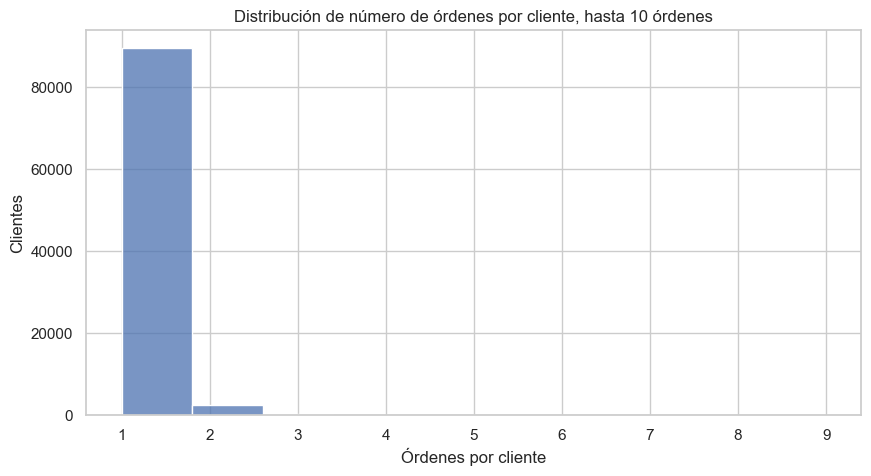

In [19]:
# Distribución de órdenes por cliente
orders_per_customer = customer_summary['n_orders'].value_counts().sort_index().reset_index()
orders_per_customer.columns = ['n_orders', 'n_customers']

display(orders_per_customer.head(20))

plt.figure(figsize=(10, 5))
sns.histplot(
    customer_summary.loc[customer_summary['n_orders'] <= 10, 'n_orders'],
    bins=10
)
plt.title('Distribución de número de órdenes por cliente, hasta 10 órdenes')
plt.xlabel('Órdenes por cliente')
plt.ylabel('Clientes')
plt.show()

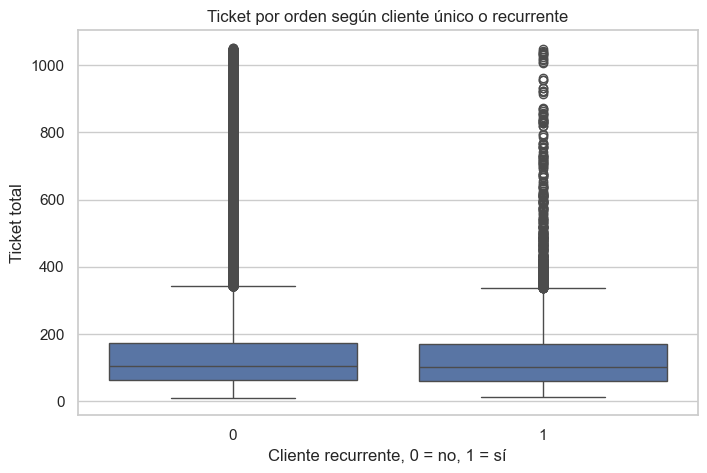

,is_repeat_customer,n_orders,avg_ticket,median_ticket,avg_items
0,0,89334,160.937,105.370,1.137
1,1,5788,146.503,101.020,1.219


In [20]:
# Comparación de ticket entre clientes únicos y recurrentes
orders = orders.merge(
    customer_summary[['customer_unique_id', 'is_repeat_customer', 'n_orders']],
    on='customer_unique_id',
    how='left',
    suffixes=('', '_customer')
)

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=orders[orders['ticket_total'] <= orders['ticket_total'].quantile(0.99)],
    x='is_repeat_customer',
    y='ticket_total'
)
plt.title('Ticket por orden según cliente único o recurrente')
plt.xlabel('Cliente recurrente, 0 = no, 1 = sí')
plt.ylabel('Ticket total')
plt.show()

repeat_ticket_summary = orders.groupby('is_repeat_customer').agg(
    n_orders=('order_id', 'nunique'),
    avg_ticket=('ticket_total', 'mean'),
    median_ticket=('ticket_total', 'median'),
    avg_items=('n_items', 'mean')
).reset_index()

display(repeat_ticket_summary)

## 8. Análisis geográfico y de pago

La ubicación y el método de pago pueden afectar tanto el ticket como el tipo de compra. Para un MVP, estas variables pueden servir como señales de contexto cuando el cliente no tiene suficiente historial.

,customer_state,n_orders,avg_ticket,revenue,avg_items
0,SP,39950,142.656,"5,699,123.850",1.147
1,RJ,12166,166.829,"2,029,637.450",1.145
2,MG,11187,160.745,"1,798,254.610",1.138
3,RS,5266,161.491,"850,413.090",1.146
4,PR,4855,159.146,"772,651.810",1.148
5,SC,3491,168.288,"587,495.070",1.156
6,BA,3215,181.608,"583,870.320",1.128
7,DF,2050,167.351,"343,068.880",1.133
8,ES,1978,159.662,"315,811.360",1.116
9,GO,1911,170.118,"325,096.200",1.164


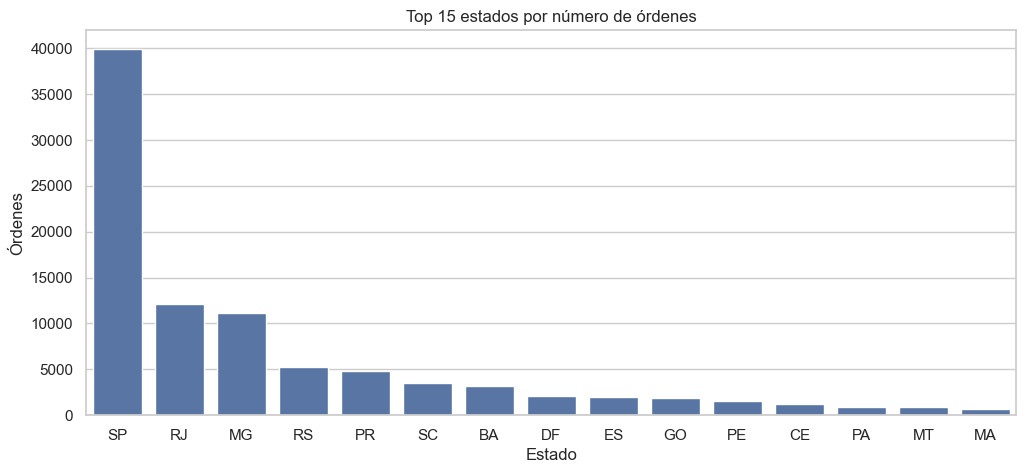

In [21]:
# Ticket promedio y volumen por estado del cliente
state_stats = orders.groupby('customer_state').agg(
    n_orders=('order_id', 'nunique'),
    avg_ticket=('ticket_total', 'mean'),
    revenue=('ticket_total', 'sum'),
    avg_items=('n_items', 'mean')
).sort_values('n_orders', ascending=False).reset_index()

display(state_stats.head(15))

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=state_stats.head(15), x='customer_state', y='n_orders', ax=ax)
ax.set_title('Top 15 estados por número de órdenes')
ax.set_xlabel('Estado')
ax.set_ylabel('Órdenes')
plt.show()

,payment_type_main,n_orders,avg_ticket,median_ticket,avg_installments
0,credit_card,72902,165.712,108.775,3.519
1,boleto,18926,144.337,93.655,1.000
2,voucher,1837,113.066,74.670,1.119
3,debit_card,1457,140.611,89.580,1.000


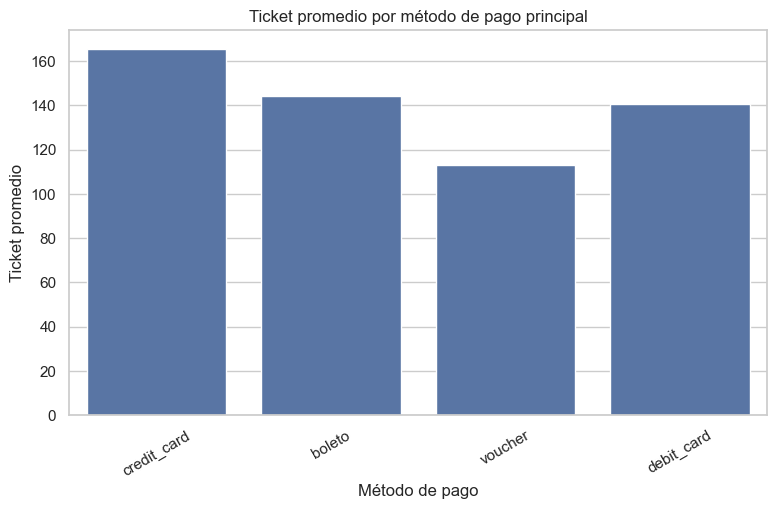

In [22]:
# Método de pago y ticket promedio
payment_stats = orders.groupby('payment_type_main').agg(
    n_orders=('order_id', 'nunique'),
    avg_ticket=('ticket_total', 'mean'),
    median_ticket=('ticket_total', 'median'),
    avg_installments=('payment_installments', 'mean')
).sort_values('n_orders', ascending=False).reset_index()

display(payment_stats)

plt.figure(figsize=(9, 5))
sns.barplot(data=payment_stats, x='payment_type_main', y='avg_ticket')
plt.title('Ticket promedio por método de pago principal')
plt.xlabel('Método de pago')
plt.ylabel('Ticket promedio')
plt.xticks(rotation=30)
plt.show()

## 9. Análisis multivariable

Aquí cruzamos variables para entender relaciones más complejas. Esto ayuda a decidir qué señales pueden ser útiles para recomendaciones y para explicar cambios en ticket promedio.

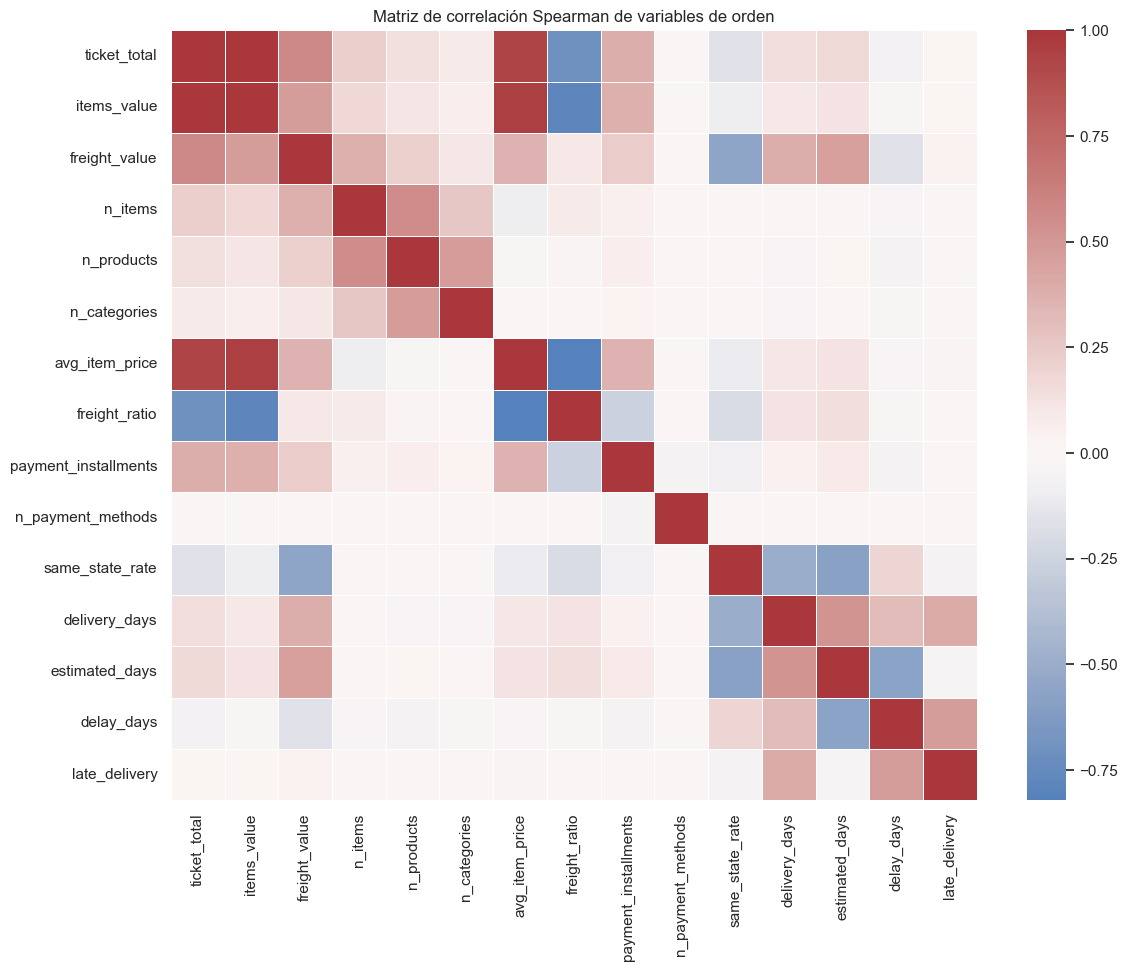

,correlacion_spearman_con_ticket
items_value,0.989
avg_item_price,0.930
freight_ratio,-0.705
freight_value,0.569
payment_installments,0.383
n_items,0.224
estimated_days,0.169
same_state_rate,-0.159
delivery_days,0.142
n_products,0.137


In [23]:
# ============================================================
# 9. Correlaciones multivariables
# ============================================================

num_cols = [
    'ticket_total',
    'items_value',
    'freight_value',
    'n_items',
    'n_products',
    'n_categories',
    'avg_item_price',
    'freight_ratio',
    'payment_installments',
    'n_payment_methods',
    'same_state_rate',
    'delivery_days',
    'estimated_days',
    'delay_days',
    'late_delivery'
]

corr = orders[num_cols].corr(method='spearman')

plt.figure(figsize=(13, 10))
sns.heatmap(corr, cmap='vlag', center=0, annot=False, linewidths=0.5)
plt.title('Matriz de correlación Spearman de variables de orden')
plt.show()

# Variables más relacionadas con ticket total
corr_ticket = corr['ticket_total'].drop('ticket_total').sort_values(key=lambda s: s.abs(), ascending=False)
display(corr_ticket.to_frame('correlacion_spearman_con_ticket'))

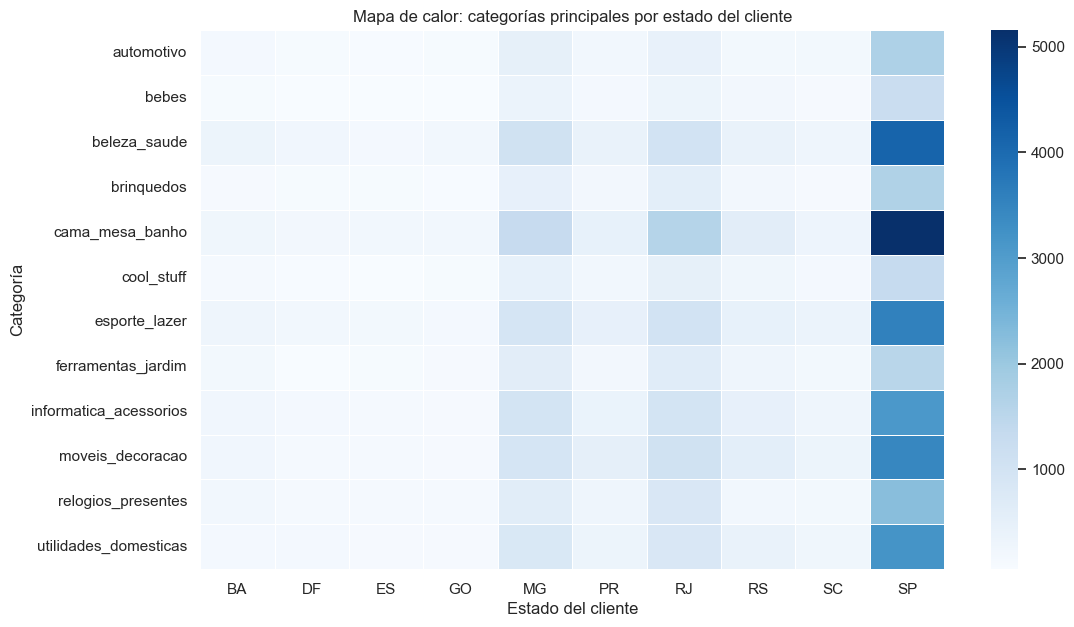

In [24]:
# Heatmap estado x categoría usando las categorías y estados con mayor volumen
TOP_N_CAT = 12
TOP_N_STATE = 10

top_cats = category_stats.head(TOP_N_CAT)['product_category_name'].tolist()
top_states = state_stats.head(TOP_N_STATE)['customer_state'].tolist()

state_cat = (
    items[items['product_category_name'].isin(top_cats) & items['customer_state'].isin(top_states)]
    .pivot_table(
        index='product_category_name',
        columns='customer_state',
        values='order_unique_id',
        aggfunc='count',
        fill_value=0
    )
)

plt.figure(figsize=(12, 7))
sns.heatmap(state_cat, cmap='Blues', linewidths=0.5)
plt.title('Mapa de calor: categorías principales por estado del cliente')
plt.xlabel('Estado del cliente')
plt.ylabel('Categoría')
plt.show()

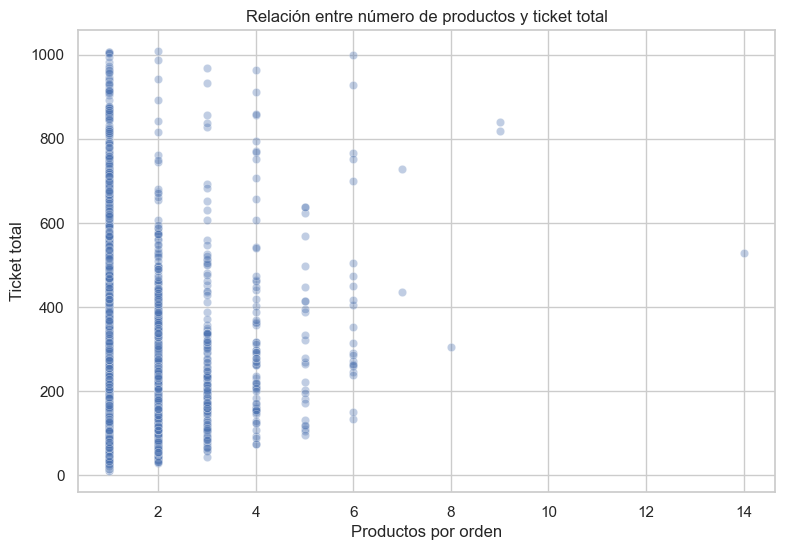

In [25]:
# Relación entre tamaño de canasta y ticket
sample_orders = orders.sample(min(12000, len(orders)), random_state=42)

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=sample_orders[sample_orders['ticket_total'] <= sample_orders['ticket_total'].quantile(0.99)],
    x='n_items',
    y='ticket_total',
    alpha=0.35
)
plt.title('Relación entre número de productos y ticket total')
plt.xlabel('Productos por orden')
plt.ylabel('Ticket total')
plt.show()

## 10. Co-ocurrencia de categorías y productos complementarios

Para recomendar productos complementarios, una primera aproximación es revisar qué categorías aparecen juntas en la misma orden. El dataset tiene muchas órdenes de una sola categoría, así que este análisis también nos dice qué tan fuerte o débil es la señal de canasta compartida.

Usaremos métricas básicas de reglas de asociación:

- **Soporte:** proporción de órdenes donde aparece el par.
- **Confianza:** probabilidad de comprar B cuando ya se compró A.
- **Lift:** qué tanto aumenta la compra conjunta frente a lo esperado por popularidad individual.

In [26]:
# ============================================================
# 10. Reglas de asociación simples por categoría
# ============================================================

order_cat_sets = orders['categories'].dropna().tolist()
order_cat_sets = [tuple(cats) for cats in order_cat_sets if len(cats) > 0]

n_orders = len(order_cat_sets)
cat_counter = Counter()
pair_counter = Counter()

for cats in order_cat_sets:
    unique_cats = sorted(set(cats))
    cat_counter.update(unique_cats)
    if len(unique_cats) >= 2:
        pair_counter.update(combinations(unique_cats, 2))

rules = []
for (cat_a, cat_b), pair_count in pair_counter.items():
    support = pair_count / n_orders
    confidence_a_to_b = pair_count / cat_counter[cat_a]
    confidence_b_to_a = pair_count / cat_counter[cat_b]
    lift = support / ((cat_counter[cat_a] / n_orders) * (cat_counter[cat_b] / n_orders))
    rules.append({
        'cat_a': cat_a,
        'cat_b': cat_b,
        'pair_orders': pair_count,
        'support': support,
        'confidence_a_to_b': confidence_a_to_b,
        'confidence_b_to_a': confidence_b_to_a,
        'lift': lift
    })

rules_df = pd.DataFrame(rules)

if len(rules_df) > 0:
    rules_df = rules_df.sort_values(['lift', 'pair_orders'], ascending=[False, False])
    display(rules_df.head(30))
else:
    print('No se encontraron pares de categorías en una misma orden.')

,cat_a,cat_b,pair_orders,support,confidence_a_to_b,confidence_b_to_a,lift
160,fashion_esporte,fashion_roupa_feminina,1,0.000,0.038,0.028,101.626
163,construcao_ferramentas_jardim,flores,1,0.000,0.005,0.034,17.264
202,fashion_bolsas_e_acessorios,fashion_roupa_infanto_juvenil,2,0.000,0.001,0.286,14.933
192,livros_tecnicos,musica,1,0.000,0.004,0.026,9.778
100,casa_conforto_2,instrumentos_musicais,1,0.000,0.042,0.002,6.487
227,cool_stuff,pc_gamer,1,0.000,0.000,0.143,3.821
76,bebes,la_cuisine,1,0.000,0.000,0.077,2.606
198,casa_construcao,construcao_ferramentas_seguranca,2,0.000,0.004,0.013,2.493
164,ferramentas_jardim,la_cuisine,1,0.000,0.000,0.077,2.123
237,construcao_ferramentas_iluminacao,construcao_ferramentas_jardim,1,0.000,0.004,0.005,2.069


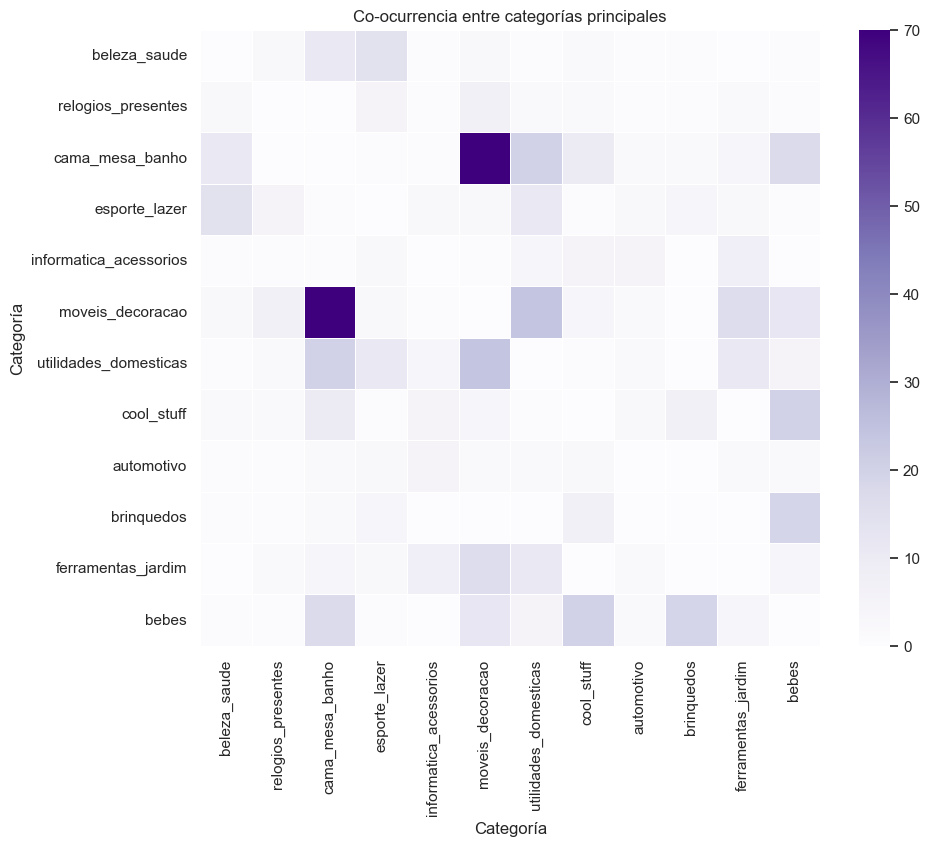

In [27]:
# Visualización de co-ocurrencia entre categorías principales
cooc_matrix = pd.DataFrame(0, index=top_cats, columns=top_cats, dtype=int)

for cats in order_cat_sets:
    cats = [c for c in cats if c in top_cats]
    for a, b in combinations(sorted(set(cats)), 2):
        cooc_matrix.loc[a, b] += 1
        cooc_matrix.loc[b, a] += 1

plt.figure(figsize=(10, 8))
sns.heatmap(cooc_matrix, cmap='Purples', linewidths=0.5)
plt.title('Co-ocurrencia entre categorías principales')
plt.xlabel('Categoría')
plt.ylabel('Categoría')
plt.show()

## 11. Evaluación offline de recomendaciones con matriz de confusión

Como no tenemos impresiones, clics ni productos recomendados reales, no podemos calcular conversión real. Para aproximarnos al problema, haremos una evaluación offline:

1. Tomamos clientes con al menos dos compras.
2. Usamos sus compras anteriores como historial.
3. Dejamos la última compra como prueba.
4. Recomendamos Top-K categorías.
5. Comparamos si las categorías recomendadas aparecen en la compra futura.

La matriz de confusión se interpreta así:

- **TP:** categoría recomendada y comprada en la compra futura.
- **FP:** categoría recomendada pero no comprada.
- **FN:** categoría comprada pero no recomendada.
- **TN:** categoría no recomendada y no comprada dentro del universo evaluado.

Esto no es una conversión real, pero funciona como una prueba inicial para saber si las recomendaciones van en una dirección razonable. Porque sí, incluso los modelos necesitan un simulacro antes de salir a decepcionar clientes reales.

In [28]:
# ============================================================
# 11. Train/test temporal para evaluación de recomendador
# ============================================================

orders_eval = orders.sort_values(['customer_unique_id', 'order_purchase_timestamp']).copy()
orders_eval['orders_per_customer'] = orders_eval.groupby('customer_unique_id')['order_id'].transform('count')

repeat_orders = orders_eval[orders_eval['orders_per_customer'] >= 2].copy()
repeat_orders['rank_order'] = repeat_orders.groupby('customer_unique_id').cumcount() + 1
repeat_orders['max_rank_order'] = repeat_orders.groupby('customer_unique_id')['rank_order'].transform('max')

train_orders = repeat_orders[repeat_orders['rank_order'] < repeat_orders['max_rank_order']].copy()
test_orders = repeat_orders[repeat_orders['rank_order'] == repeat_orders['max_rank_order']].copy()

print('Clientes evaluables con al menos 2 compras:', f"{test_orders['customer_unique_id'].nunique():,}")
print('Órdenes de entrenamiento:', f'{len(train_orders):,}')
print('Órdenes de prueba:', f'{len(test_orders):,}')

Clientes evaluables con al menos 2 compras: 2,741
Órdenes de entrenamiento: 3,047
Órdenes de prueba: 2,741


In [29]:
# ============================================================
# 12. Recomendador base por co-ocurrencia + popularidad
# ============================================================

K = 5
CANDIDATE_TOP_N = 50

# Popularidad global en entrenamiento
train_category_list = [cat for cats in train_orders['categories'] for cat in cats]
global_category_ranking = [cat for cat, _ in Counter(train_category_list).most_common()]

# Historial de categorías por cliente
customer_history = train_orders.groupby('customer_unique_id')['categories'].agg(
    lambda vals: tuple(sorted(set(cat for cats in vals for cat in cats)))
).to_dict()

# Co-ocurrencia de categorías dentro de la misma orden
cooc_scores = defaultdict(Counter)

for cats in train_orders['categories']:
    unique_cats = sorted(set(cats))
    for cat_a in unique_cats:
        for cat_b in unique_cats:
            if cat_a != cat_b:
                cooc_scores[cat_a][cat_b] += 1


def recommend_categories(customer_id, k=K):
    # Recomienda categorías usando historial del cliente, co-ocurrencia y popularidad.
    seen = set(customer_history.get(customer_id, tuple()))
    scores = Counter()
    
    for cat in seen:
        scores.update(cooc_scores.get(cat, Counter()))
    
    # Primero categorías complementarias no vistas
    recommendations = [cat for cat, _ in scores.most_common() if cat not in seen]
    
    # Fallback: categorías populares no vistas
    if len(recommendations) < k:
        recommendations += [
            cat for cat in global_category_ranking
            if cat not in recommendations and cat not in seen
        ]
    
    # Segundo fallback: popularidad general, incluyendo repetición si ya no hay suficientes categorías nuevas
    if len(recommendations) < k:
        recommendations += [
            cat for cat in global_category_ranking
            if cat not in recommendations
        ]
    
    return recommendations[:k]

# Ejemplo de recomendaciones
example_customer = test_orders['customer_unique_id'].iloc[0]
print('Cliente ejemplo:', example_customer)
print('Historial:', customer_history.get(example_customer))
print('Recomendaciones:', recommend_categories(example_customer, K))

Cliente ejemplo: 004288347e5e88a27ded2bb23747066c
Historial: ('cool_stuff',)
Recomendaciones: ['cama_mesa_banho', 'relogios_presentes', 'esporte_lazer', 'moveis_decoracao', 'beleza_saude']


In [30]:
# ============================================================
# 13. Matriz de confusión para recomendación Top-K
# ============================================================

candidate_categories = set(global_category_ranking[:CANDIDATE_TOP_N])

y_true = []
y_pred = []
hit_at_k = []
rows_eval = []

for row in test_orders.itertuples():
    customer_id = row.customer_unique_id
    actual_categories = set(row.categories)
    recommended_categories = set(recommend_categories(customer_id, K))
    
    hit_at_k.append(int(bool(actual_categories & recommended_categories)))
    
    # Universo evaluado: top categorías + categorías reales + categorías recomendadas
    universe = candidate_categories | actual_categories | recommended_categories
    
    for cat in universe:
        actual = int(cat in actual_categories)
        predicted = int(cat in recommended_categories)
        y_true.append(actual)
        y_pred.append(predicted)
        rows_eval.append({
            'customer_unique_id': customer_id,
            'category': cat,
            'actual_purchase_future': actual,
            'recommended': predicted
        })

eval_df = pd.DataFrame(rows_eval)

cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)
hit_rate = np.mean(hit_at_k)

metrics_recommender = pd.DataFrame({
    'Métrica': [
        f'Precision@{K}, aproximada como matriz binaria',
        f'Recall@{K}, aproximada como matriz binaria',
        'F1',
        f'Hit Rate@{K}',
        'Clientes evaluados',
        'Categorías candidatas'
    ],
    'Valor': [
        precision,
        recall,
        f1,
        hit_rate,
        test_orders['customer_unique_id'].nunique(),
        len(candidate_categories)
    ]
})

display(metrics_recommender)
print(classification_report(y_true, y_pred, target_names=['No comprada', 'Comprada'], zero_division=0))

,Métrica,Valor
0,"Precision@5, aproximada como matriz binaria",0.041
1,"Recall@5, aproximada como matriz binaria",0.204
2,F1,0.069
3,Hit Rate@5,0.204
4,Clientes evaluados,"2,741.000"
5,Categorías candidatas,50.000


              precision    recall  f1-score   support

 No comprada       0.98      0.90      0.94    134400
    Comprada       0.04      0.20      0.07      2781

    accuracy                           0.89    137181
   macro avg       0.51      0.55      0.50    137181
weighted avg       0.96      0.89      0.92    137181



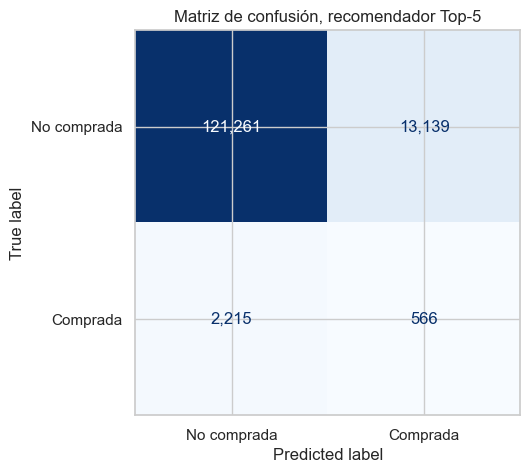

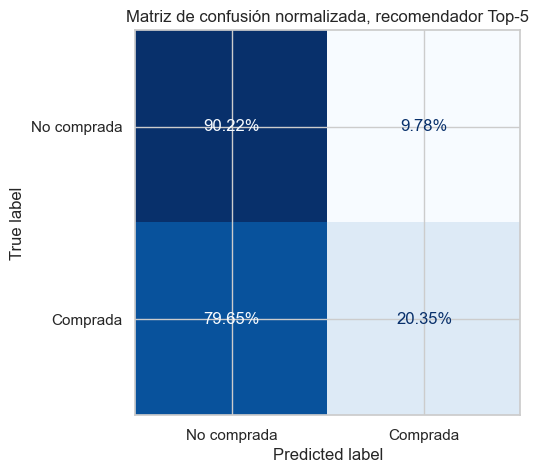

In [31]:
# Diagrama de confusión absoluto
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['No comprada', 'Comprada']
)
disp.plot(values_format=',d', cmap='Blues', ax=ax, colorbar=False)
ax.set_title(f'Matriz de confusión, recomendador Top-{K}')
plt.show()

# Diagrama de confusión normalizado por clase real
cm_norm = confusion_matrix(y_true, y_pred, labels=[0, 1], normalize='true')

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_norm,
    display_labels=['No comprada', 'Comprada']
)
disp.plot(values_format='.2%', cmap='Blues', ax=ax, colorbar=False)
ax.set_title(f'Matriz de confusión normalizada, recomendador Top-{K}')
plt.show()

## 12. Interpretación para el proyecto

Este EDA deja varias conclusiones útiles para el Sprint 1:

1. **La conversión real no se puede medir directamente con este CSV**, porque faltan datos de exposición a recomendaciones, visitas, clics, carritos y compras no realizadas.
2. **El ticket promedio sí puede analizarse directamente**, usando el valor pagado o el valor de productos más flete a nivel orden.
3. **La personalización tiene un reto fuerte de cold start**, porque muchos clientes tienen una sola compra.
4. **Las recomendaciones iniciales deberían ser híbridas**, combinando popularidad, categoría, co-ocurrencia y contexto geográfico.
5. **La matriz de confusión del recomendador debe interpretarse como evaluación offline**, no como conversión real.
6. **Para el MVP**, conviene comenzar con:
   - recomendador por popularidad para clientes nuevos,
   - recomendador por co-ocurrencia para productos/categorías complementarias,
   - recomendador por historial para clientes recurrentes,
   - evaluación con Precision@K, Recall@K, HitRate@K y ticket promedio de las categorías recomendadas.

El siguiente paso natural sería construir un baseline formal y compararlo contra un modelo item-item o category-category, validando si aumenta el acierto sobre compras futuras y si las recomendaciones tienden a categorías de mayor ticket.

In [32]:
# Guardado opcional de tablas procesadas para reutilizarlas en modelado o dashboard
OUTPUT_DIR = Path('outputs_eda_recomendacion')
OUTPUT_DIR.mkdir(exist_ok=True)

orders.to_csv(OUTPUT_DIR / 'orders_analytic.csv', index=False)
customer_summary.to_csv(OUTPUT_DIR / 'customers_analytic.csv', index=False)
category_stats.to_csv(OUTPUT_DIR / 'category_stats.csv', index=False)
eval_df.to_csv(OUTPUT_DIR / 'recommender_eval_binary.csv', index=False)

print('Archivos exportados en:', OUTPUT_DIR.resolve())

Archivos exportados en: C:\Users\Ismael2\Downloads\outputs_eda_recomendacion
